# Yağmur Tahmini

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ8PQF6jAVmGXSghRQS44vFy8p5tA0iyENfQw&s">

Bu çalışmada, meteorolojik veriler kullanılarak belirli bir günde yağmur oluşup oluşmayacağının tahmin edilmesi amaçlanmakta olup, problem ikili sınıflandırma (binary classification) yaklaşımıyla ele alınmaktadır.

## Sütun Açıklamaları

**day**

→ Gözlemin yapıldığı takvim gününü temsil eder ve zaman sıralaması bilgisini içerir.

**pressure**

→ Atmosfer basıncını (hPa) gösterir ve düşük basınç genellikle yağış ihtimalini artırabilir.

**maxtemp**

→ Gün içerisinde ölçülen en yüksek sıcaklığı ifade eder.

**temparature**

→ Günlük ortalama sıcaklığı temsil eder (muhtemelen “temperature” yazım hatalıdır).

**mintemp**

→ Gün içinde kaydedilen en düşük sıcaklığı gösterir.

**dewpoint**

→ Havanın doygunluğa ulaştığı sıcaklığı gösterir ve nem ile doğrudan ilişkilidir.

**humidity**

→ Bağıl nem oranını (%) gösterir ve yağmur oluşumu için kritik bir faktördür.

**cloud**

→ Bulutluluk oranını temsil eder; yüksek değerler yağış ihtimalini artırabilir.

**rainfall (Hedef Değişken)**

→ O gün yağmur yağıp yağmadığını belirten ikili sınıf değişkenidir (yes = yağmur var, no = yağmur yok).

**sunshine**

→ Günlük güneşlenme süresini (saat cinsinden) ifade eder; genellikle düşük güneş süresi yağışla ilişkilidir.

**winddirection**

→ Rüzgarın estiği yönü derece cinsinden gösterir.

**windspeed**

→ Rüzgar hızını ifade eder ve hava sistemlerinin hareketiyle ilişkilidir.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/yags-tahmini/Rainfall.csv


In [18]:
# Temel veri işleme
import numpy as np
import pandas as pd

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Uyarıları kapatalım
import warnings
warnings.filterwarnings("ignore")

#Veri bölme
from sklearn.model_selection import train_test_split

# Ölçekleme
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Encoding
from sklearn.preprocessing import LabelEncoder

# Modeller
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/yags-tahmini/Rainfall.csv")

df.head()


,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [4]:
df.shape

(366, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [6]:
df.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [7]:
df.columns


Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [29]:
df.isnull().sum()

day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    1
windspeed        1
dtype: int64

In [31]:
df["winddirection"].fillna(df["winddirection"].median(), inplace=True)
df["windspeed"].fillna(df["windspeed"].median(), inplace=True)


In [40]:
df.isnull().sum()

day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

In [19]:
df["rainfall"] = df["rainfall"].map({"yes": 1, "no": 0})


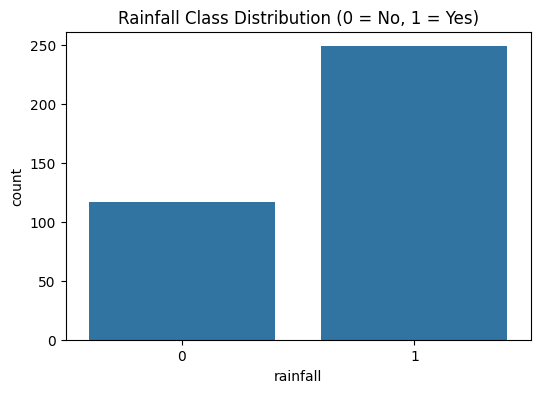

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x="rainfall", data=df)
plt.title("Rainfall Class Distribution (0 = No, 1 = Yes)")
plt.show()


Veri setinde yağmurlu günler (1) yağmursuz günlere (0) göre daha fazladır, ancak sınıflar aşırı dengesiz değildir.

In [35]:
df.columns = df.columns.str.strip()


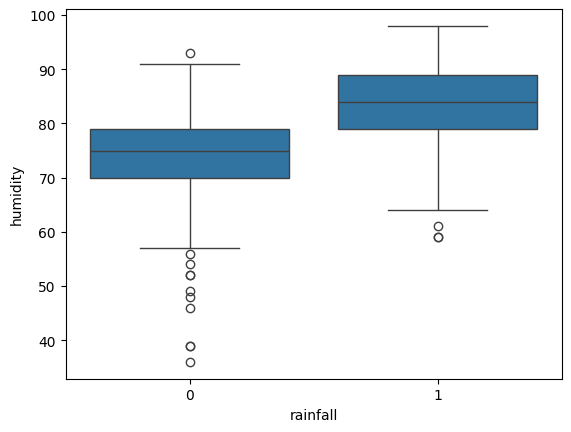

In [36]:
sns.boxplot(x="rainfall", y="humidity", data=df)
plt.show()

Yağmurlu günlerde nem (humidity) medyan değeri belirgin şekilde daha yüksektir, bu da nemin yağış için güçlü bir belirleyici olduğunu göstermektedir.

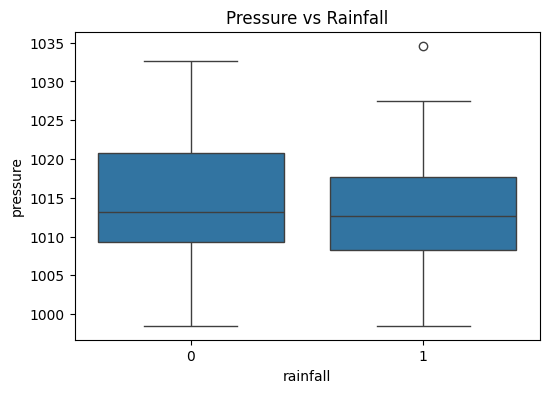

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(x="rainfall", y="pressure", data=df)
plt.title("Pressure vs Rainfall")
plt.show()


Yağmurlu günlerde basınç değerleri hafifçe daha düşük eğilim gösterse de fark çok güçlü değildir.

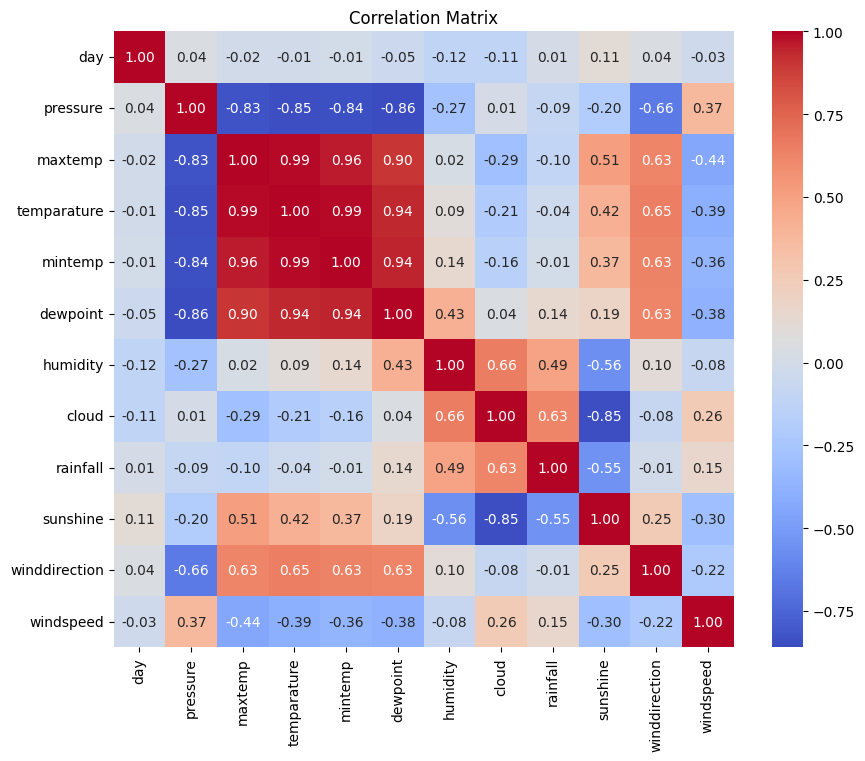

In [38]:
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


Rainfall değişkeni en güçlü pozitif korelasyonu bulutluluk (cloud) ve nem (humidity) ile, en güçlü negatif korelasyonu ise güneşlenme süresi (sunshine) ile göstermektedir.

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            366 non-null    int64  
 1   pressure       366 non-null    float64
 2   maxtemp        366 non-null    float64
 3   temparature    366 non-null    float64
 4   mintemp        366 non-null    float64
 5   dewpoint       366 non-null    float64
 6   humidity       366 non-null    int64  
 7   cloud          366 non-null    int64  
 8   rainfall       366 non-null    int64  
 9   sunshine       366 non-null    float64
 10  winddirection  366 non-null    float64
 11  windspeed      366 non-null    float64
dtypes: float64(8), int64(4)
memory usage: 34.4 KB


In [42]:
x = df.drop("rainfall", axis=1)
y = df["rainfall"]


In [44]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y # Sınıf dağılımını train ve testte aynı tutar.
)


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model1 = LogisticRegression(max_iter=1000)

model1.fit(x_train, y_train)

pred1 = model1.predict(x_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred1))


Logistic Regression Accuracy: 0.8108108108108109


In [52]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(random_state=42)

model2.fit(x_train, y_train)

pred2 = model2.predict(x_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred2))


Decision Tree Accuracy: 0.7297297297297297


In [53]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier(random_state=42)

model3.fit(x_train, y_train)

pred3 = model3.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred3))


Random Forest Accuracy: 0.7837837837837838


In [54]:
from sklearn.ensemble import GradientBoostingClassifier

model4 = GradientBoostingClassifier(random_state=42)

model4.fit(x_train, y_train)

pred4 = model4.predict(x_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, pred4))


Gradient Boosting Accuracy: 0.8108108108108109


In [55]:
from sklearn.neighbors import KNeighborsClassifier

model5 = KNeighborsClassifier()

model5.fit(x_train, y_train)

pred5 = model5.predict(x_test)

print("KNN Accuracy:", accuracy_score(y_test, pred5))


KNN Accuracy: 0.7297297297297297


In [56]:
from sklearn.svm import SVC

model6 = SVC()

model6.fit(x_train, y_train)

pred6 = model6.predict(x_test)

print("SVM Accuracy:", accuracy_score(y_test, pred6))


SVM Accuracy: 0.6756756756756757


In [57]:
print(
    "Logistic Regression:", accuracy_score(y_test, pred1),
    "\nDecision Tree:", accuracy_score(y_test, pred2),
    "\nRandom Forest:", accuracy_score(y_test, pred3),
    "\nGradient Boosting:", accuracy_score(y_test, pred4),
    "\nKNN:", accuracy_score(y_test, pred5),
    "\nSVM:", accuracy_score(y_test, pred6)
)


Logistic Regression: 0.8108108108108109 
Decision Tree: 0.7297297297297297 
Random Forest: 0.7837837837837838 
Gradient Boosting: 0.8108108108108109 
KNN: 0.7297297297297297 
SVM: 0.6756756756756757


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd


def algo_test_classification(x, y):
    
    # Modeller
    LR  = LogisticRegression(max_iter=1000)
    NB  = GaussianNB()
    GB  = GradientBoostingClassifier(random_state=42)
    ET  = ExtraTreesClassifier(random_state=42)
    KNN = KNeighborsClassifier()
    DT  = DecisionTreeClassifier(random_state=42)
    SVM = SVC()
    
    algos = [LR, NB, GB, ET, KNN, DT, SVM]
    
    algo_names = [
        'Logistic Regression',
        'Naive Bayes',
        'Gradient Boosting',
        'Extra Trees',
        'KNN',
        'Decision Tree',
        'SVM'
    ]
    
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
    )
    
    accuracy = []
    f1 = []
    
    result = pd.DataFrame(columns=['Accuracy', 'F1_Score'], index=algo_names)
    
    for algo in algos:
        p = algo.fit(x_train, y_train).predict(x_test)
        
        accuracy.append(accuracy_score(y_test, p))
        f1.append(f1_score(y_test, p))
    
    result['Accuracy'] = accuracy
    result['F1_Score'] = f1
    
    return result.sort_values('Accuracy', ascending=False)


In [59]:
algo_test_classification(x, y)


,Accuracy,F1_Score
Naive Bayes,0.837838,0.880000
Logistic Regression,0.810811,0.867925
Gradient Boosting,0.810811,0.867925
Extra Trees,0.770270,0.838095
KNN,0.729730,0.814815
Decision Tree,0.729730,0.791667
SVM,0.675676,0.806452


## Şimdi rastgele bir gün ele alalım ve yağmurlu olup olmadığına bakalım

In [60]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(x, y)


GaussianNB()

In [61]:
random_day = x.sample(1, random_state=42)
random_day


,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
193,12,1003.8,29.0,28.1,27.0,25.1,84,88,0.0,230.0,16.3


In [62]:
prediction = model.predict(random_day)[0]
probability = model.predict_proba(random_day)[0]

print("Seçilen Gün:")
print(random_day)

print("\nTahmin:", "Yağmur Var" if prediction == 1 else "Yağmur Yok")
print("Yağmur Olasılığı:", round(probability[1], 3))


Seçilen Gün:
     day  pressure  maxtemp  temparature  mintemp  dewpoint  humidity  cloud  \
193   12    1003.8     29.0         28.1     27.0      25.1        84     88   

     sunshine  winddirection  windspeed  
193       0.0          230.0       16.3  

Tahmin: Yağmur Var
Yağmur Olasılığı: 0.996


Model, düşük basınç, yüksek nem ve sıfır güneşlenme süresi gibi yağışı destekleyen meteorolojik koşullara dayanarak seçilen günün %99.6 olasılıkla yağmurlu olacağını tahmin etmiştir.

## Sonuç

Elde edilen sonuçlara göre en yüksek performans %83.78 doğruluk ve %88 F1 skoru ile Naive Bayes modeli tarafından sağlanmış olup, bu veri setinde olasılıksal yaklaşımın diğer modellere kıyasla daha başarılı çalıştığı görülmektedir; Logistic Regression ve Gradient Boosting modelleri benzer performans gösterirken en düşük doğruluk oranı SVM modelinde elde edilmiştir. Örnek olarak seçilen rastgele bir satırdaki özelliklere göre de o gün yağmur olup olmaması ve yağmur yağma olasılığı tahmin edilmiştir.